In [1]:
import pandas as pd

file_path = r"C:\Users\PC\IELTS-Writing-Evals\dataset\asap\training_set_rel3.tsv"

df = pd.read_csv(
    file_path,
    sep="\t",
    encoding="latin-1"
)

df.head()

,essay_id,essay_set,essay,rater1_domain1,rater2_domain1,rater3_domain1,domain1_score,rater1_domain2,rater2_domain2,domain2_score,...,rater2_trait3,rater2_trait4,rater2_trait5,rater2_trait6,rater3_trait1,rater3_trait2,rater3_trait3,rater3_trait4,rater3_trait5,rater3_trait6
0,1,1,"Dear local newspaper, I think effects computer...",4,4,NaN,8,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,"Dear @CAPS1 @CAPS2, I believe that using compu...",5,4,NaN,9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,"Dear, @CAPS1 @CAPS2 @CAPS3 More and more peopl...",4,3,NaN,7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,"Dear Local Newspaper, @CAPS1 I have found that...",5,5,NaN,10,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,"Dear @LOCATION1, I know having computers has a...",4,4,NaN,8,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df = df[["essay_id", "essay_set", "essay", "domain1_score"]].copy()

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12976 entries, 0 to 12975
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   essay_id       12976 non-null  int64 
 1   essay_set      12976 non-null  int64 
 2   essay          12976 non-null  object
 3   domain1_score  12976 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 405.6+ KB


,essay_id,essay_set,essay,domain1_score
0,1,1,"Dear local newspaper, I think effects computer...",8
1,2,1,"Dear @CAPS1 @CAPS2, I believe that using compu...",9
2,3,1,"Dear, @CAPS1 @CAPS2 @CAPS3 More and more peopl...",7
3,4,1,"Dear Local Newspaper, @CAPS1 I have found that...",10
4,5,1,"Dear @LOCATION1, I know having computers has a...",8


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# clean text nhẹ
df["essay"] = (
    df["essay"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# tạo feature độ dài
df["char_count"] = df["essay"].str.len()
df["word_count"] = df["essay"].str.split().apply(len)
df["sentence_count"] = df["essay"].str.count(r"[.!?]+")

# normalize score theo từng essay_set
score_ranges = {
    1: (2, 12),
    2: (1, 6),
    3: (0, 3),
    4: (0, 3),
    5: (0, 4),
    6: (0, 4),
    7: (0, 30),
    8: (0, 60),
}

def normalize_score(row):
    lo, hi = score_ranges[row["essay_set"]]
    return (row["domain1_score"] - lo) / (hi - lo)

df["score_norm"] = df.apply(normalize_score, axis=1)

In [5]:
df.shape


(12976, 8)

In [6]:
df.isna().sum()


essay_id          0
essay_set         0
essay             0
domain1_score     0
char_count        0
word_count        0
sentence_count    0
score_norm        0
dtype: int64

In [ ]:
df["essay_set"].value_counts().sort_index()

essay_set
1    1783
2    1800
3    1726
4    1770
5    1805
6    1800
7    1569
8     723
Name: count, dtype: int64

In [7]:
eda_table = df.groupby("essay_set").agg(
    n_essays=("essay_id", "count"),
    score_min=("domain1_score", "min"),
    score_max=("domain1_score", "max"),
    score_mean=("domain1_score", "mean"),
    score_std=("domain1_score", "std"),
    norm_score_mean=("score_norm", "mean"),
    avg_word_count=("word_count", "mean"),
    median_word_count=("word_count", "median"),
    min_word_count=("word_count", "min"),
    max_word_count=("word_count", "max")
).round(2)

eda_table

,n_essays,score_min,score_max,score_mean,score_std,norm_score_mean,avg_word_count,median_word_count,min_word_count,max_word_count
essay_set,,,,,,,,,,
1,1783,2,12,8.53,1.54,0.65,365.68,365.0,8,785
2,1800,1,6,3.42,0.77,0.48,380.75,368.0,31,1064
3,1726,0,3,1.85,0.82,0.62,108.69,100.5,10,375
4,1770,0,3,1.43,0.94,0.48,94.51,87.0,2,357
5,1805,0,4,2.41,0.97,0.60,122.13,119.0,4,416
6,1800,0,4,2.72,0.97,0.68,153.30,153.0,3,454
7,1569,2,24,16.06,4.59,0.54,168.20,154.0,5,592
8,723,10,60,36.95,5.75,0.62,604.87,626.0,4,856


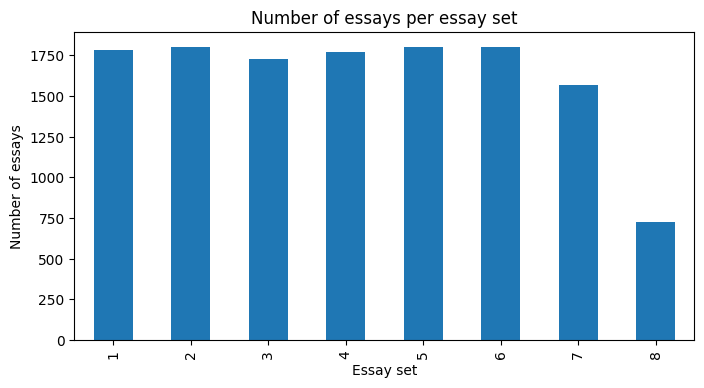

In [8]:
counts = df["essay_set"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
counts.plot(kind="bar")
plt.xlabel("Essay set")
plt.ylabel("Number of essays")
plt.title("Number of essays per essay set")
plt.show()

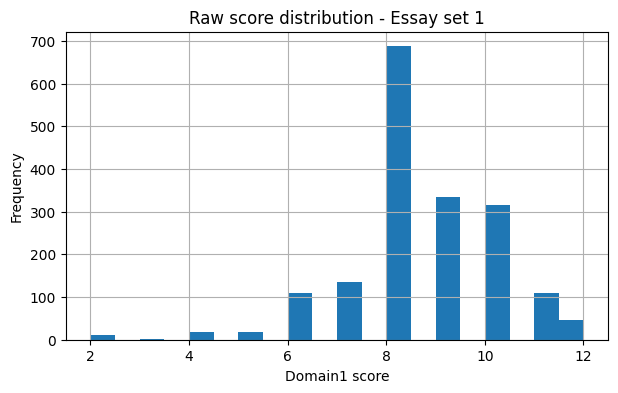

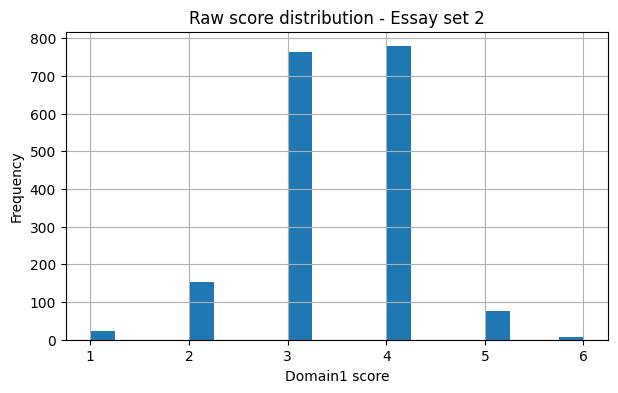

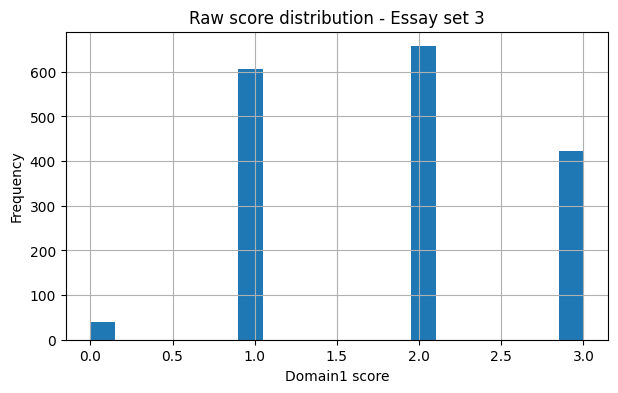

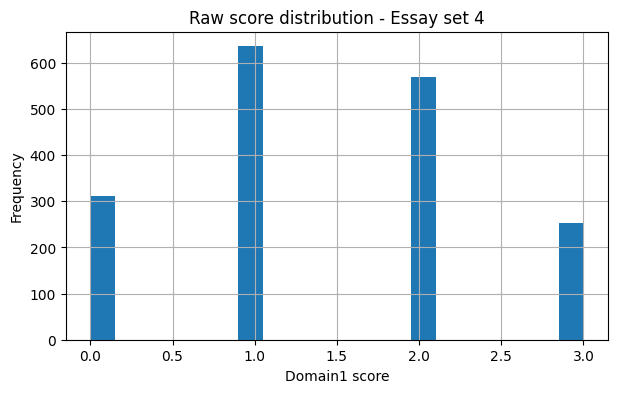

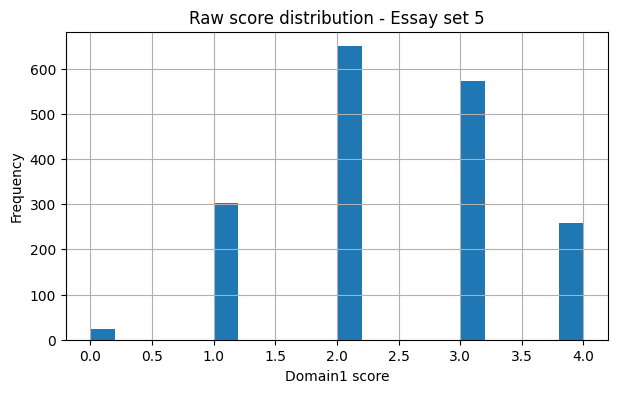

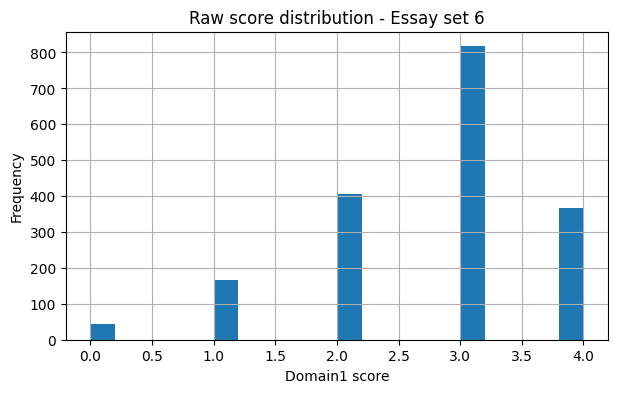

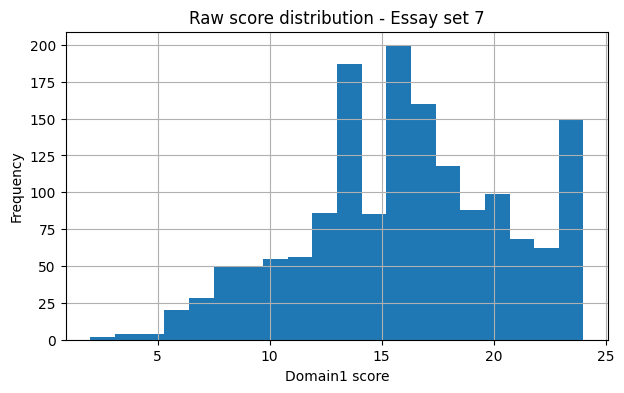

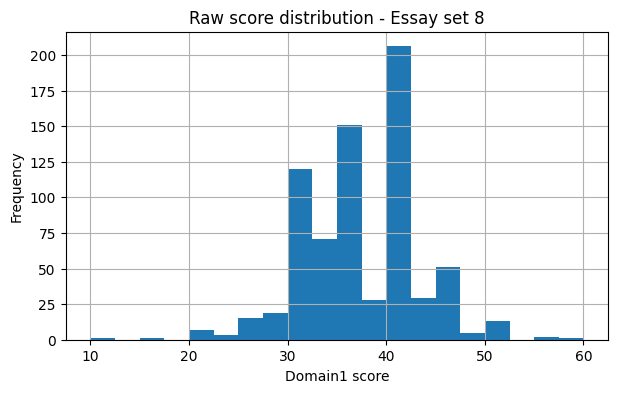

In [9]:
for essay_set in sorted(df["essay_set"].unique()):
    subset = df[df["essay_set"] == essay_set]

    plt.figure(figsize=(7, 4))
    subset["domain1_score"].hist(bins=20)
    plt.xlabel("Domain1 score")
    plt.ylabel("Frequency")
    plt.title(f"Raw score distribution - Essay set {essay_set}")
    plt.show()

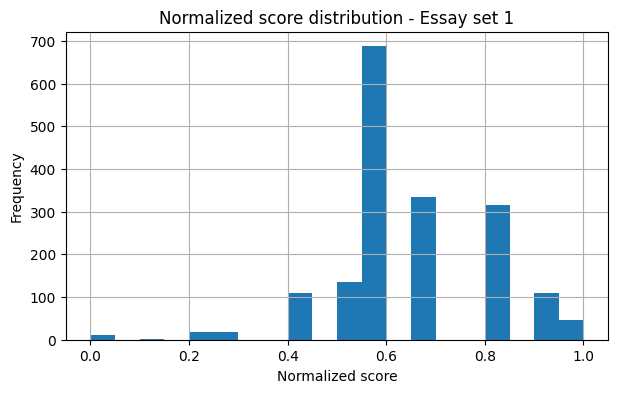

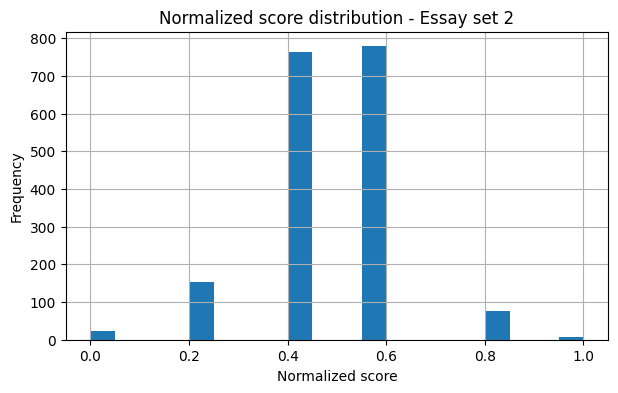

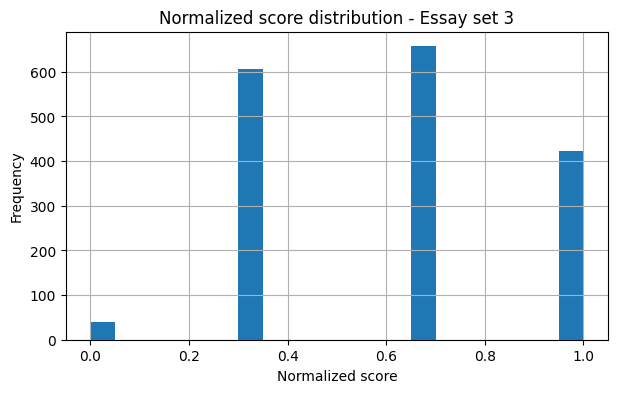

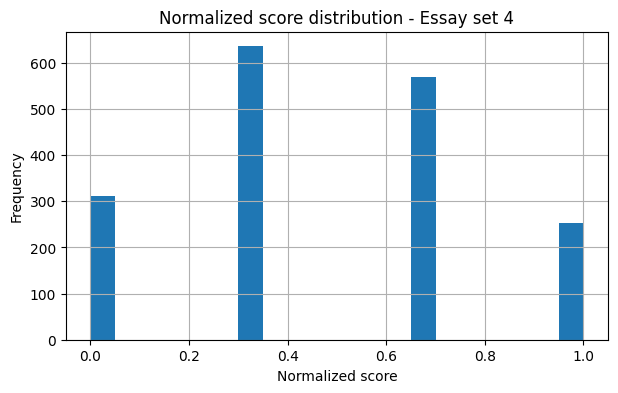

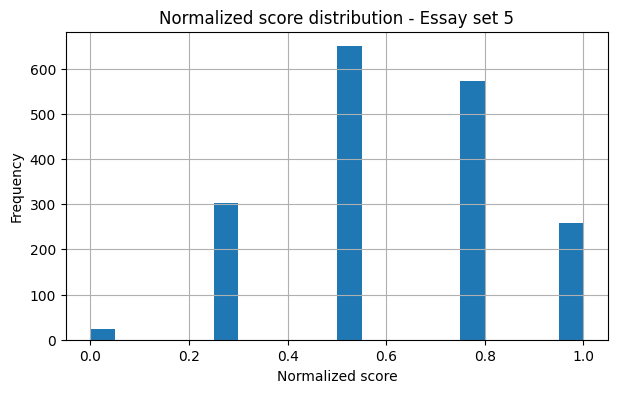

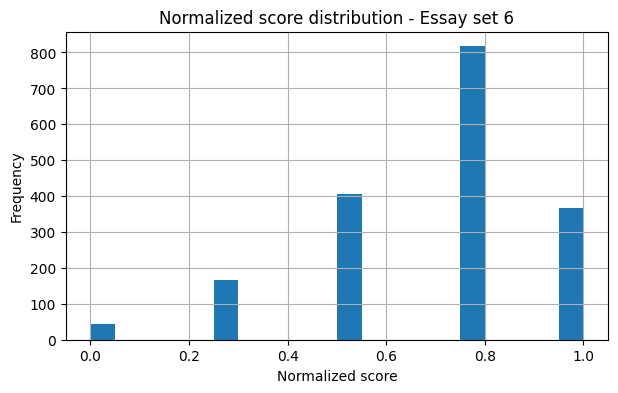

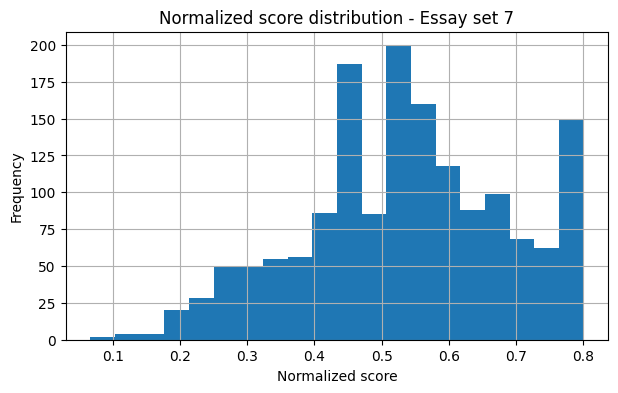

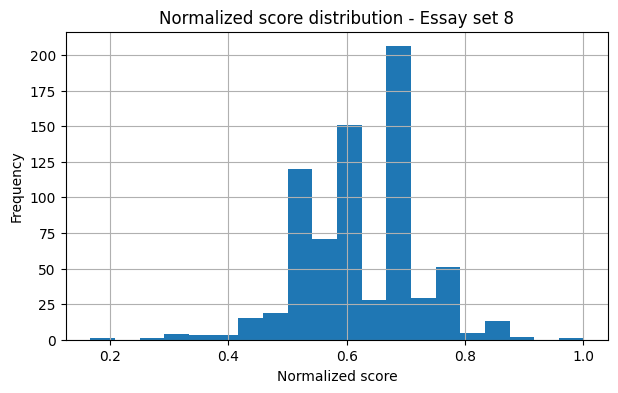

In [10]:
for essay_set in sorted(df["essay_set"].unique()):
    subset = df[df["essay_set"] == essay_set]

    plt.figure(figsize=(7, 4))
    subset["score_norm"].hist(bins=20)
    plt.xlabel("Normalized score")
    plt.ylabel("Frequency")
    plt.title(f"Normalized score distribution - Essay set {essay_set}")
    plt.show()

<Figure size 1000x500 with 0 Axes>

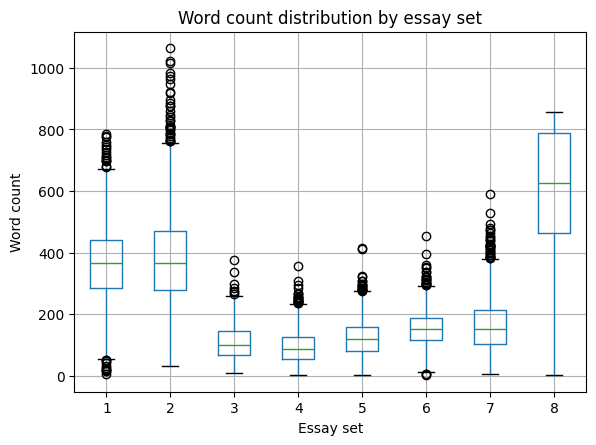

In [11]:
plt.figure(figsize=(10, 5))
df.boxplot(column="word_count", by="essay_set")
plt.xlabel("Essay set")
plt.ylabel("Word count")
plt.title("Word count distribution by essay set")
plt.suptitle("")
plt.show()

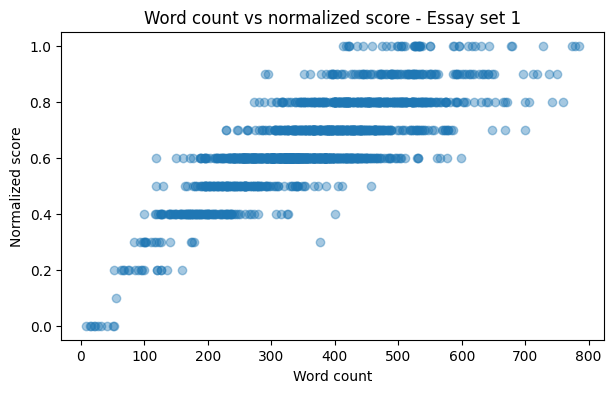

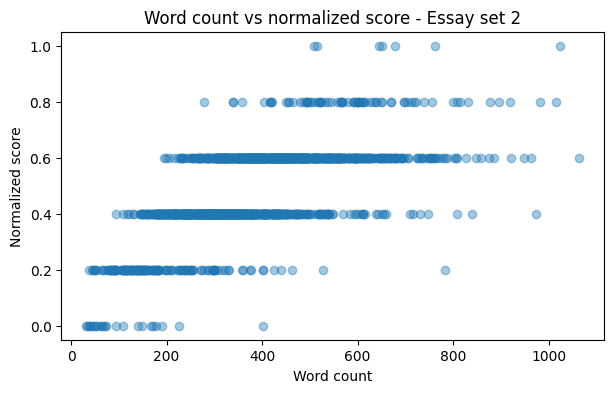

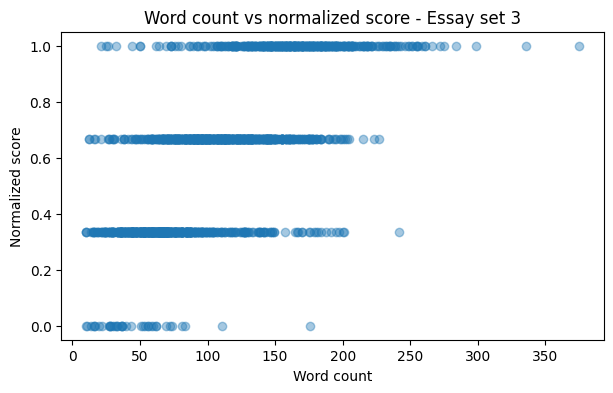

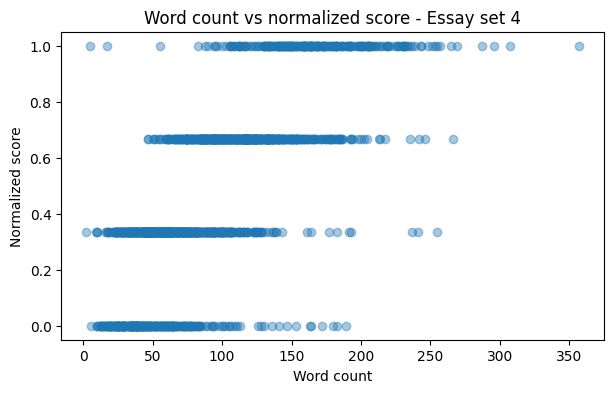

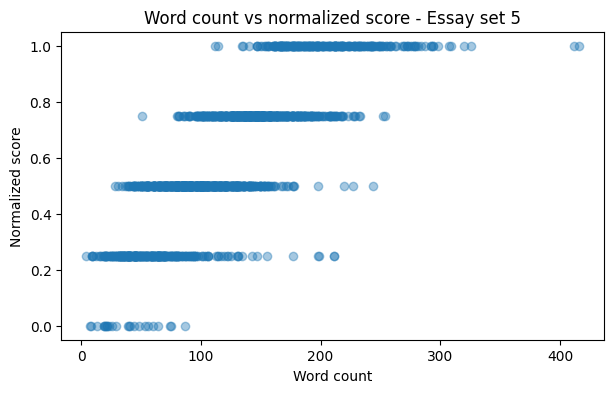

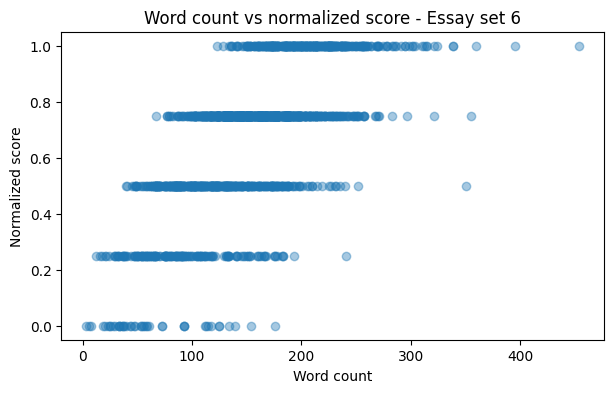

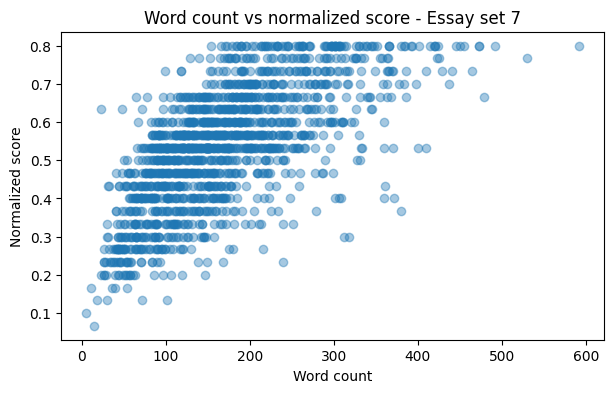

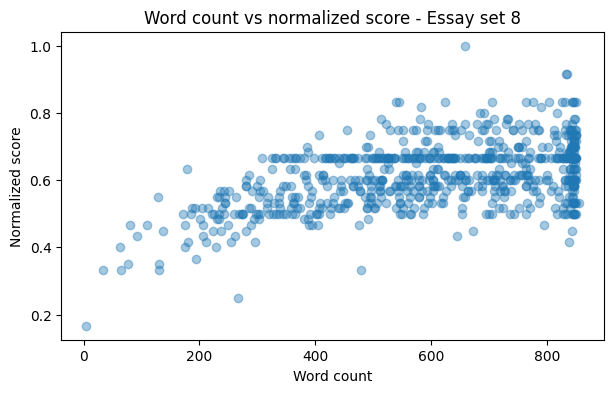

In [12]:
for essay_set in sorted(df["essay_set"].unique()):
    subset = df[df["essay_set"] == essay_set]

    plt.figure(figsize=(7, 4))
    plt.scatter(subset["word_count"], subset["score_norm"], alpha=0.4)
    plt.xlabel("Word count")
    plt.ylabel("Normalized score")
    plt.title(f"Word count vs normalized score - Essay set {essay_set}")
    plt.show()